In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

C:\Users\moham\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df = pd.read_csv('feature_engineering_tv.csv')
df.head()

,Unnamed: 0,index,brand,ultra_hd,full_hd,Price,Rating,inches,display_type,wifi,rom,hdmi_port,value_score,smart_features,Company_amazon,Company_croma,Company_flipkart,brand_score,ppi,resolution_width,resolution_height,fast_charging,ram,usb_port,Spec_Score,size_category,charging_category
0,0,1,tcl,1,0,42999,4.65,55.0,qled,1,16.0,1,0.006272,4.0,0.0,0.0,1.0,8.0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0
1,1,2,lg,1,0,41999,4.55,55.0,led,1,19.2,1,0.005958,3.0,0.0,0.0,1.0,10.0,3.0,1.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0
2,2,3,xiaomi,1,0,36999,4.35,55.0,qled,1,32.0,1,0.006466,4.0,1.0,0.0,0.0,8.0,3.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0
3,3,4,lg,1,0,30999,4.40,43.0,led,1,19.2,1,0.007381,3.0,0.0,0.0,1.0,10.0,4.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0
4,4,5,philips,1,0,74999,4.05,75.0,qled,1,32.0,1,0.003618,4.0,1.0,0.0,0.0,8.0,1.0,1.0,2.0,2.0,1.0,1.0,4.0,1.0,2.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   index              1000 non-null   int64  
 2   brand              1000 non-null   object 
 3   ultra_hd           1000 non-null   int64  
 4   full_hd            1000 non-null   int64  
 5   Price              1000 non-null   int64  
 6   Rating             1000 non-null   float64
 7   inches             1000 non-null   float64
 8   display_type       1000 non-null   object 
 9   wifi               1000 non-null   int64  
 10  rom                1000 non-null   float64
 11  hdmi_port          1000 non-null   int64  
 12  value_score        1000 non-null   float64
 13  smart_features     1000 non-null   float64
 14  Company_amazon     1000 non-null   float64
 15  Company_croma      1000 non-null   float64
 16  Company_flipkart   1000 n

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Unnamed: 0            0
index                 0
brand                 0
ultra_hd              0
full_hd               0
Price                 0
Rating                0
inches                0
display_type          0
wifi                  0
rom                   0
hdmi_port             0
value_score           0
smart_features        0
Company_amazon        0
Company_croma         0
Company_flipkart      0
brand_score          30
ppi                   0
resolution_width      0
resolution_height     0
fast_charging         0
ram                   0
usb_port              0
Spec_Score            0
size_category         0
charging_category     0
dtype: int64

In [12]:
df.sample(10)

,Unnamed: 0,index,brand,ultra_hd,full_hd,Price,Rating,inches,display_type,wifi,rom,hdmi_port,value_score,smart_features,Company_amazon,Company_croma,Company_flipkart,brand_score,ppi,resolution_width,resolution_height,fast_charging,ram,usb_port,Spec_Score,size_category,charging_category
981,981,982,acer,1,0,100999,4.35,75.0,qled,1,16.0,1,0.003144,4.0,1.0,0.0,0.0,7.0,1.0,1.0,2.0,3.0,1.0,1.0,4.0,1.0,1.0
131,131,132,lg,1,0,44999,4.20,43.0,miniled,1,19.2,1,0.005133,3.0,0.0,0.0,1.0,10.0,4.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0
715,715,716,lg,1,0,69990,4.65,65.0,led,1,19.2,1,0.003521,4.0,0.0,0.0,1.0,10.0,2.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0
84,84,85,tcl,1,0,47990,4.35,55.0,qled,1,16.0,1,0.005439,4.0,0.0,1.0,0.0,8.0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0
739,739,740,lloyd,1,0,28599,4.45,43.0,qled,1,19.2,1,0.007158,4.0,0.0,0.0,1.0,5.0,4.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0,2.0
352,352,353,kodak,1,0,32999,4.45,55.0,qled,1,22.4,1,0.007687,4.0,0.0,0.0,1.0,6.0,3.0,1.0,2.0,3.0,1.0,1.0,3.0,1.0,0.0
489,489,490,haier,1,0,49090,4.45,55.0,qled,1,32.0,1,0.005439,4.0,0.0,1.0,0.0,7.0,3.0,1.0,2.0,2.0,1.0,1.0,3.0,1.0,2.0
515,515,516,tcl,1,0,34900,4.30,55.0,led,1,22.4,1,0.006037,3.0,0.0,0.0,1.0,8.0,3.0,1.0,2.0,1.0,1.0,0.0,1.0,1.0,2.0
925,925,926,tcl,1,0,34990,4.35,55.0,led,1,16.0,1,0.006216,3.0,1.0,0.0,0.0,8.0,3.0,1.0,2.0,1.0,1.0,0.0,1.0,1.0,2.0
531,531,532,vw,1,0,55199,4.60,75.0,qled,1,32.0,1,0.005500,4.0,1.0,0.0,0.0,NaN,1.0,1.0,2.0,3.0,1.0,1.0,3.0,1.0,1.0


In [13]:
df['brand_score'].describe()

count    970.000000
mean       7.538144
std        2.238395
min        1.000000
25%        6.000000
50%        8.000000
75%       10.000000
max       10.000000
Name: brand_score, dtype: float64

In [14]:
brand_score = ['brand_score']

In [15]:
from sklearn.impute import SimpleImputer
si_impute = SimpleImputer(fill_value=7)
si_train = si_impute.fit_transform(df[brand_score])

In [16]:
si_df = pd.DataFrame(si_train,
                    columns = brand_score,
                    index = df.index)

In [18]:
df = pd.concat([df.drop(columns = brand_score), si_df], axis=1)

In [23]:
df.isnull().sum()

index                0
brand                0
ultra_hd             0
full_hd              0
Price                0
Rating               0
inches               0
display_type         0
wifi                 0
rom                  0
hdmi_port            0
value_score          0
smart_features       0
Company_amazon       0
Company_croma        0
Company_flipkart     0
ppi                  0
resolution_width     0
resolution_height    0
fast_charging        0
ram                  0
usb_port             0
Spec_Score           0
size_category        0
charging_category    0
brand_score          0
dtype: int64

In [22]:
df = df.drop(columns = ['Unnamed: 0'])

# Univarite Analysis

## Price Column

In [27]:
df['Price'].describe()

count    1.000000e+03
mean     6.667263e+04
std      1.178397e+05
min      4.494000e+03
25%      2.299900e+04
50%      3.749000e+04
75%      6.812175e+04
max      2.699999e+06
Name: Price, dtype: float64

In [80]:
df['Price'] = np.log1p(df['Price'])

In [81]:
df['Price'].describe()

count    1000.000000
mean       10.609192
std         0.919269
min         8.410721
25%        10.043249
50%        10.531856
75%        11.129062
max        14.808762
Name: Price, dtype: float64

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Axes: xlabel='Price', ylabel='Density'>

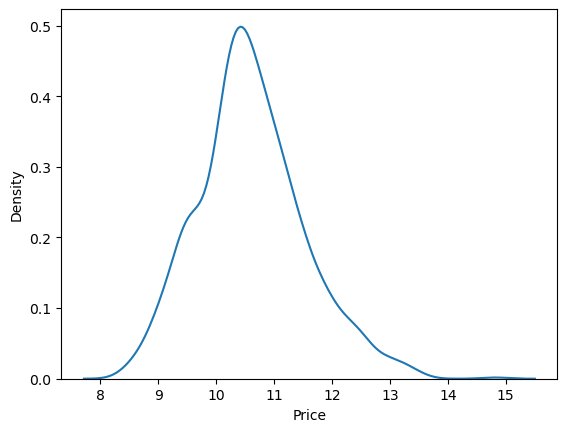

In [82]:
sns.kdeplot(data=df, x='Price')

<Axes: xlabel='Price'>

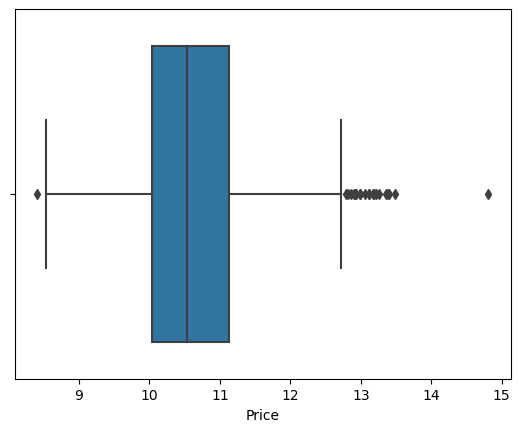

In [83]:
sns.boxplot(data=df, x='Price')

In [84]:
df['Price'].skew()

0.46074023708518397

## Rating Column

In [85]:
df['Rating'].describe()

count    1000.000000
mean        4.377450
std         0.231403
min         4.000000
25%         4.200000
50%         4.350000
75%         4.600000
max         4.750000
Name: Rating, dtype: float64

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Axes: xlabel='Rating', ylabel='Density'>

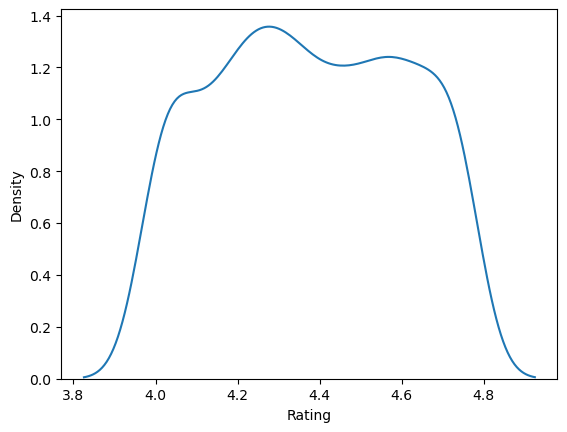

In [86]:
sns.kdeplot(data=df, x='Rating')

<Axes: xlabel='Rating'>

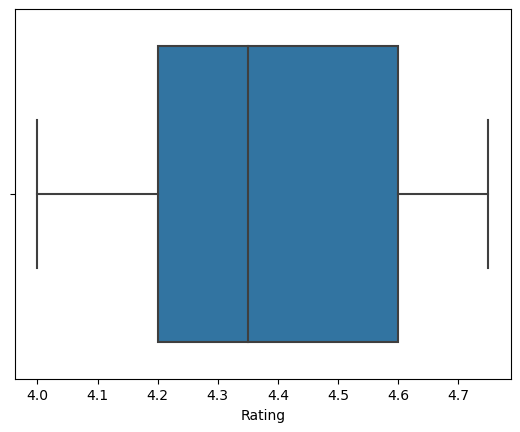

In [87]:
sns.boxplot(data=df, x='Rating')

In [88]:
df['Rating'].skew()

-0.0014399731822773852

## Spec_Score

In [89]:
df['Spec_Score'].describe()

count    1000.000000
mean        2.054000
std         1.432877
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Spec_Score, dtype: float64

C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Axes: xlabel='Spec_Score', ylabel='Density'>

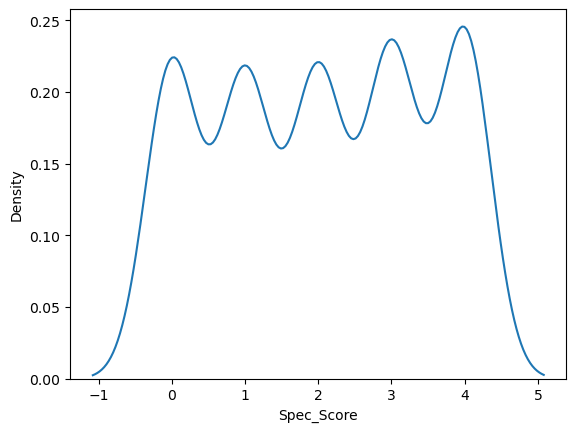

In [90]:
sns.kdeplot(data=df, x='Spec_Score')

<Axes: xlabel='Spec_Score'>

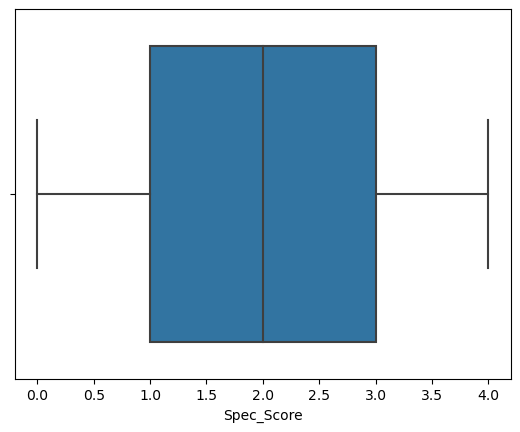

In [91]:
sns.boxplot(data=df, x='Spec_Score')

## Inches

In [92]:
df['inches'].describe()

count    1000.000000
mean       53.146120
std        15.575851
min        23.620000
25%        43.000000
50%        55.000000
75%        65.000000
max       120.000000
Name: inches, dtype: float64

In [93]:
px.histogram(df, 'inches', color='display_type')

C:\ProgramData\anaconda3\lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



C:\ProgramData\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Axes: xlabel='inches', ylabel='Density'>

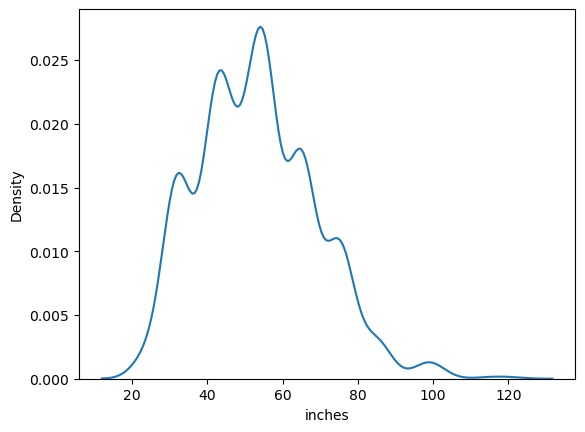

In [94]:
sns.kdeplot(data=df, x='inches')

<Axes: xlabel='inches'>

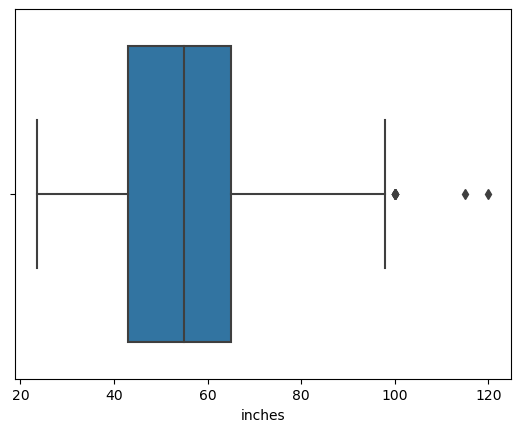

In [95]:
sns.boxplot(data=df, x='inches')

In [96]:
df['inches'].skew()

0.524650828297288

# Bivarite Analysis

In [97]:
df.head()

,index,brand,ultra_hd,full_hd,Price,Rating,inches,display_type,wifi,rom,hdmi_port,value_score,smart_features,Company_amazon,Company_croma,Company_flipkart,ppi,resolution_width,resolution_height,fast_charging,ram,usb_port,Spec_Score,size_category,charging_category,brand_score
0,1,tcl,1,0,10.668955,4.65,55.0,qled,1,16.0,1,0.006272,4.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0,8.0
1,2,lg,1,0,10.645425,4.55,55.0,led,1,19.2,1,0.005958,3.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0,10.0
2,3,xiaomi,1,0,10.518673,4.35,55.0,qled,1,32.0,1,0.006466,4.0,1.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,8.0
3,4,lg,1,0,10.341742,4.40,43.0,led,1,19.2,1,0.007381,3.0,0.0,0.0,1.0,4.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0,10.0
4,5,philips,1,0,11.225243,4.05,75.0,qled,1,32.0,1,0.003618,4.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,4.0,1.0,2.0,8.0


## Numerical to Numerical

### Price to Rating Columns

In [98]:
px.scatter(df, x='Rating', y='Price', color='brand')

C:\ProgramData\anaconda3\lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



### Price to Inches Columns

<Axes: xlabel='inches', ylabel='Price'>

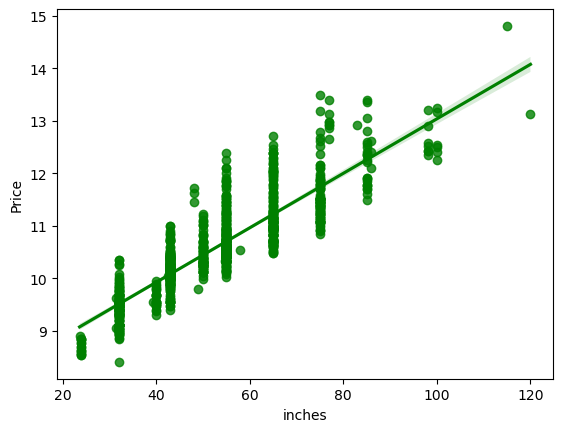

In [99]:
sns.regplot(data=df, x='inches', y='Price', color="g")

### Price to Spec_Score Columns

In [100]:
px.histogram(df, x='Spec_Score', y='Price', color='brand')

C:\ProgramData\anaconda3\lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



# Numerical to Categorical

### Price to Brand Columns

In [101]:
px.scatter(df, x='brand', y='Price', color='display_type', size='Rating', animation_frame='display_type')

### Price to Display_Type Columns

In [102]:
px.bar(df, x='display_type', y='Price', color='display_type', animation_frame='Rating')

# Categorical to Categorical

In [103]:
df.head()

,index,brand,ultra_hd,full_hd,Price,Rating,inches,display_type,wifi,rom,hdmi_port,value_score,smart_features,Company_amazon,Company_croma,Company_flipkart,ppi,resolution_width,resolution_height,fast_charging,ram,usb_port,Spec_Score,size_category,charging_category,brand_score
0,1,tcl,1,0,10.668955,4.65,55.0,qled,1,16.0,1,0.006272,4.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0,8.0
1,2,lg,1,0,10.645425,4.55,55.0,led,1,19.2,1,0.005958,3.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0,10.0
2,3,xiaomi,1,0,10.518673,4.35,55.0,qled,1,32.0,1,0.006466,4.0,1.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,8.0
3,4,lg,1,0,10.341742,4.40,43.0,led,1,19.2,1,0.007381,3.0,0.0,0.0,1.0,4.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0,10.0
4,5,philips,1,0,11.225243,4.05,75.0,qled,1,32.0,1,0.003618,4.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,4.0,1.0,2.0,8.0


<Axes: xlabel='display_type'>

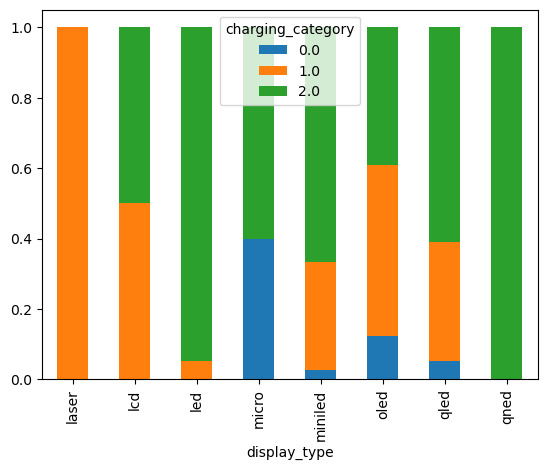

In [104]:
pd.crosstab(df['display_type'],df['charging_category'],normalize='index').plot(kind='bar',stacked=True)

<Axes: >

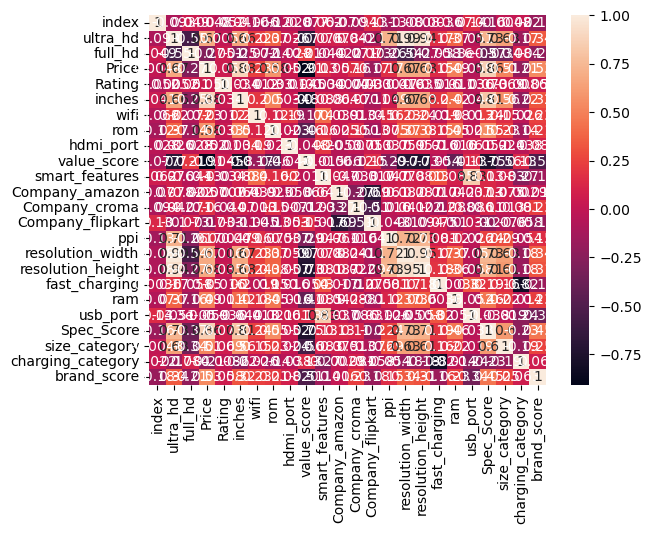

In [105]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

In [106]:
df.head()

,index,brand,ultra_hd,full_hd,Price,Rating,inches,display_type,wifi,rom,hdmi_port,value_score,smart_features,Company_amazon,Company_croma,Company_flipkart,ppi,resolution_width,resolution_height,fast_charging,ram,usb_port,Spec_Score,size_category,charging_category,brand_score
0,1,tcl,1,0,10.668955,4.65,55.0,qled,1,16.0,1,0.006272,4.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,2.0,8.0
1,2,lg,1,0,10.645425,4.55,55.0,led,1,19.2,1,0.005958,3.0,0.0,0.0,1.0,3.0,1.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0,10.0
2,3,xiaomi,1,0,10.518673,4.35,55.0,qled,1,32.0,1,0.006466,4.0,1.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,8.0
3,4,lg,1,0,10.341742,4.40,43.0,led,1,19.2,1,0.007381,3.0,0.0,0.0,1.0,4.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,2.0,10.0
4,5,philips,1,0,11.225243,4.05,75.0,qled,1,32.0,1,0.003618,4.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,4.0,1.0,2.0,8.0


In [107]:
df.to_csv('television_eda.csv')